/opt/anaconda3/envs/2026统计建模赛/lib/python3.10/site-packages/sksurv/linear_model/coxph.py:492: LinAlgWarning: Ill-conditioned matrix (rcond=4.43619e-20): result may not be accurate.
/opt/anaconda3/envs/2026统计建模赛/lib/python3.10/site-packages/sksurv/linear_model/coxph.py:492: LinAlgWarning: Ill-conditioned matrix (rcond=1.0206e-19): result may not be accurate.
/opt/anaconda3/envs/2026统计建模赛/lib/python3.10/site-packages/sksurv/linear_model/coxph.py:492: LinAlgWarning: Ill-conditioned matrix (rcond=1.24481e-19): result may not be accurate.
/opt/anaconda3/envs/2026统计建模赛/lib/python3.10/site-packages/sksurv/linear_model/coxph.py:492: LinAlgWarning: Ill-conditioned matrix (rcond=2.5621e-19): result may not be accurate.


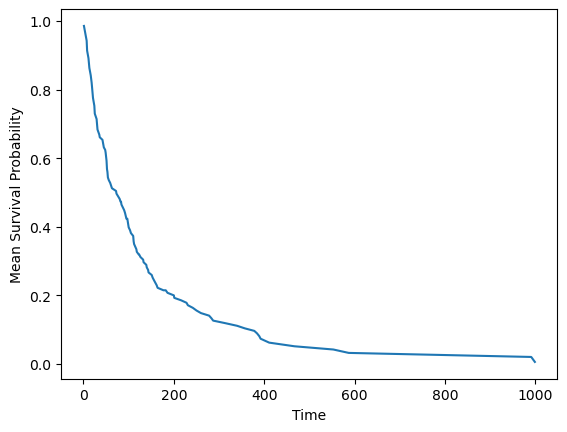

In [100]:
import numpy as np
import pandas as pd
from sksurv.datasets import load_veterans_lung_cancer
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sklearn.feature_extraction.text import TfidfVectorizer
import seaborn as sns
import matplotlib.pyplot as plt

X,y = load_veterans_lung_cancer()

X = pd.DataFrame(X)

X['Prior_therapy'] = X['Prior_therapy'].apply(lambda x: 1 if x == 'yes' else 0)
X['Treatment'] = X['Treatment'].apply(lambda x: 1 if x == 'standard' else 0)

vt = TfidfVectorizer()
vt.fit(X['Celltype'])
celltype_encoded = vt.transform(X['Celltype'])
celltype_df = pd.DataFrame(celltype_encoded.toarray(), columns=vt.get_feature_names_out())
X = pd.concat([X.drop('Celltype', axis=1), celltype_df], axis=1)

cph = CoxPHSurvivalAnalysis()
cph.fit(X, y)

h = cph.predict_survival_function(X)
x = pd.Series([func.x for func in h])
y = pd.Series([func.y for func in h])
sns.lineplot(x=x.mean(), y=y.mean())
plt.xlabel('Time')
plt.ylabel('Mean Survival Probability')
plt.show()